In [1]:
import cmasher as cmr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Load simulation 

# Directory path from Flatiron server
dir_path = '/mnt/home/tudomlumleart/ceph/04_MitoticChromosome/dataset/ellenberg/27003022/20250918_2CondPop_GrowCubic_Heteropolymer_Step_EquilibrationTimestep_DT40Opt_Sister_20250919_BestModel_BothCond/1'
dir_path = Path(dir_path)

# Load polymer data
poly_fpath = dir_path / "all_conformations.npy"
poly = np.load(poly_fpath)

# Load Condensin 1D location
smc_pos_fpath = dir_path / "SMC_pos_0.npy"
smc_pos = np.load(smc_pos_fpath)

# Load Condensin property
smc_props_fpath = dir_path / "SMC_props_0.npy"
smc_props = np.load(smc_props_fpath)

In [3]:
# Check polymer dimension
polymer_array_dim = poly.shape
print(
    f"Number of timepoints = {polymer_array_dim[0]}\n",
    f"Number of monomers = {polymer_array_dim[1]}\n",
    f"Number of dimensions = {polymer_array_dim[2]}",
)

Number of timepoints = 31
 Number of monomers = 100000
 Number of dimensions = 3


In [4]:
# Timepoint array for polymer structure
# Correspond to minutes in physical time
timepoint_list = [1, 2, 5, 8, 15, 29]

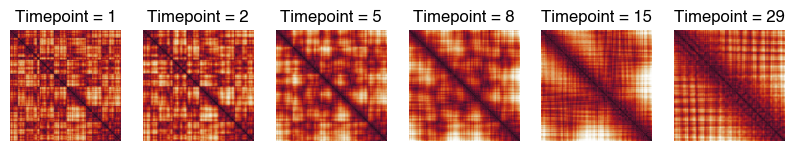

In [5]:
from scipy.spatial.distance import squareform, pdist

# Generate distance maps from polymers that have been downsampling by 100
dmap_list = [squareform(pdist(poly[timepoint, ::100])) for timepoint in timepoint_list]

# Plot distance map as a function of time
fig, axs = plt.subplots(1, len(dmap_list), figsize=(10, 20))
for idx_ax, ax in enumerate(axs.flatten()):
    ax.imshow(dmap_list[idx_ax], cmap=cmr.sunburst, vmin=0, vmax=100)
    ax.axis('off')
    ax.set_title(f'Timepoint = {timepoint_list[idx_ax]}')

In [6]:
# Check smc_pos dimension
smc_pos_array_dim = smc_pos.shape
print(
    f"Number of timepoints = {smc_pos_array_dim[0]}\n",
    f"Number of condensins = {smc_pos_array_dim[1]}\n",
    f"Number of heads per condensin = {smc_pos_array_dim[2]}",
)

Number of timepoints = 1800
 Number of condensins = 1400
 Number of heads per condensin = 2


In [7]:
# Check smc_props dimension
smc_props_array_dim = smc_props.shape
print(
    f"Number of timepoints = {smc_props_array_dim[0]}\n",
    f"Number of condensins = {smc_props_array_dim[1]}\n",
    f"Number of properties per condensin = {smc_props_array_dim[2]}",
)

Number of timepoints = 1800
 Number of condensins = 1400
 Number of properties per condensin = 4


In [8]:
# Key point: we downsample 1D condensin array by 60 times before passing it to the MD simulation 
# Therefore the timepoint index mapping is 1 (3D timestep) <-> 60 (1D timestep).
# The following example will make it clearer.

# Make sure that loop size increases a function of time 
# Make sure that the 3D distance between two heads from a given condensin is close to 0
loop_size_timepoint = [[[] for t in timepoint_list] for c in range(2)] 
cond_arm_dist_timepoint = [[[] for t in timepoint_list] for c in range(2)] 
for idx_timepoint, timepoint in enumerate(timepoint_list):
    curr_poly = poly[timepoint]
    curr_smc_pos = smc_pos[timepoint*60] # Note timepoint*60 here because of the aforementioned downsampling
    curr_smc_props = smc_props[timepoint*60] # Note timepoint*60 here because of the aforementioned downsampling
    
    for condensin_type in range(2):
        # curr_smc_props[..., ..., 0] records the bound status
        # can be either 0 (unbound) or 1 (bound)
        condensin_bound_bool = curr_smc_props[:, 0] == 1

        # condensin_props_array[..., ..., -1] records the condensin type
        # can be either 0 (condensin 1) or 1 (condensin 2)
        condensin_type_bool = curr_smc_props[:, -1] == condensin_type

        # Now select bound with the correct types 
        condensin_bool = (condensin_type_bool) & (condensin_bound_bool)

        # 1D location of condensin of interest
        bound_condensin_pos = curr_smc_pos[condensin_bool]
        
        # Calculate loop size
        loop_size = np.squeeze(np.diff(bound_condensin_pos), axis=1)
        
        # Add it to the list
        loop_size_timepoint[condensin_type][idx_timepoint] = loop_size
        
        # Find 3D position of condensin arms
        condensin_3d_pos = np.array([curr_poly[bound_condensin_pos[:, 0]], curr_poly[bound_condensin_pos[:, 1]]])
        condensin_3d_pos = condensin_3d_pos.transpose([1, 0, 2])
        
        # Calculate 3D distance between arms
        condensin_3d_dist = np.linalg.norm(np.squeeze(np.diff(condensin_3d_pos, axis=1)), axis=-1)
        cond_arm_dist_timepoint[condensin_type][idx_timepoint] = condensin_3d_dist

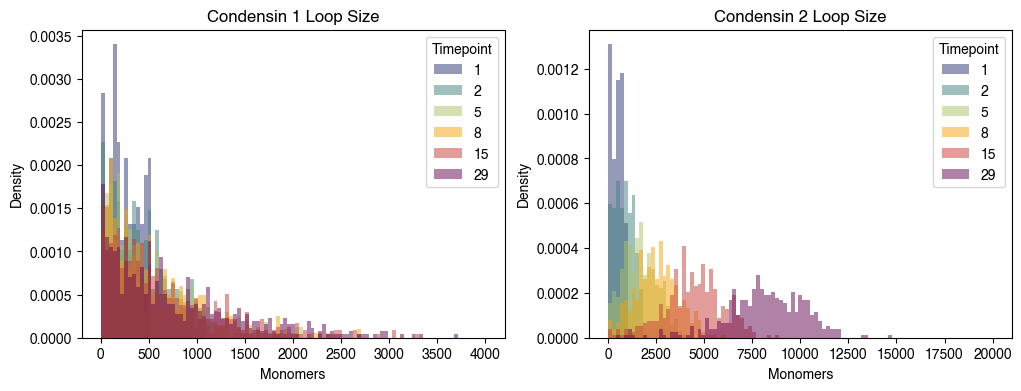

In [11]:
# Plot the loop size distribution as a function of time 
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
xbins_list = [np.linspace(0, 4000, 100),
              np.linspace(0, 20000, 100),]
sample_names = ['Condensin 1 Loop Size', 'Condensin 2 Loop Size']
colors = cmr.take_cmap_colors('cmr.pride', len(timepoint_list), cmap_range=(0.1, 0.9))
for idx_ax, ax in enumerate(axs.flatten()):
    for idx_timepoint in range(len(timepoint_list)):
        ax.hist(loop_size_timepoint[idx_ax][idx_timepoint], 
                xbins_list[idx_ax], alpha=0.5, color=colors[idx_timepoint], 
                density=True, label=timepoint_list[idx_timepoint])
    ax.set_title(sample_names[idx_ax])
    ax.legend(title='Timepoint')
    ax.set_ylabel('Density')
    ax.set_xlabel('Monomers')
    

# Note the condensin loop size increases as a function of time 

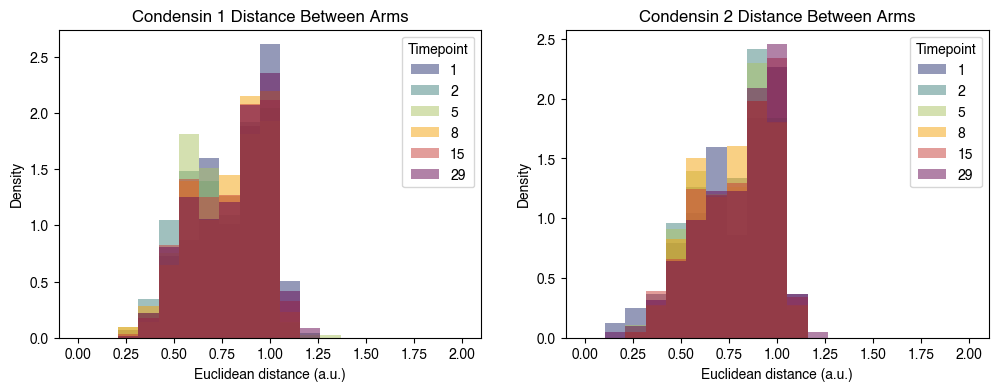

In [10]:
# Plot the loop size distribution as a function of time 
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
xbins_list = [np.linspace(0, 2, 20),
              np.linspace(0, 2, 20),]
sample_names = ['Condensin 1 Distance Between Arms', 'Condensin 2 Distance Between Arms']
colors = cmr.take_cmap_colors('cmr.pride', len(timepoint_list), cmap_range=(0.1, 0.9))
for idx_ax, ax in enumerate(axs.flatten()):
    for idx_timepoint in range(len(timepoint_list)):
        ax.hist(cond_arm_dist_timepoint[idx_ax][idx_timepoint], 
                xbins_list[idx_ax], alpha=0.5, color=colors[idx_timepoint], 
                density=True, label=timepoint_list[idx_timepoint])
    ax.set_title(sample_names[idx_ax])
    ax.legend(title='Timepoint')
    ax.set_ylabel('Density')
    ax.set_xlabel('Euclidean distance (a.u.)')
    
# Note that the distance between arms from the same condensin molecule is mostly around 1 unit which is the setting we put in

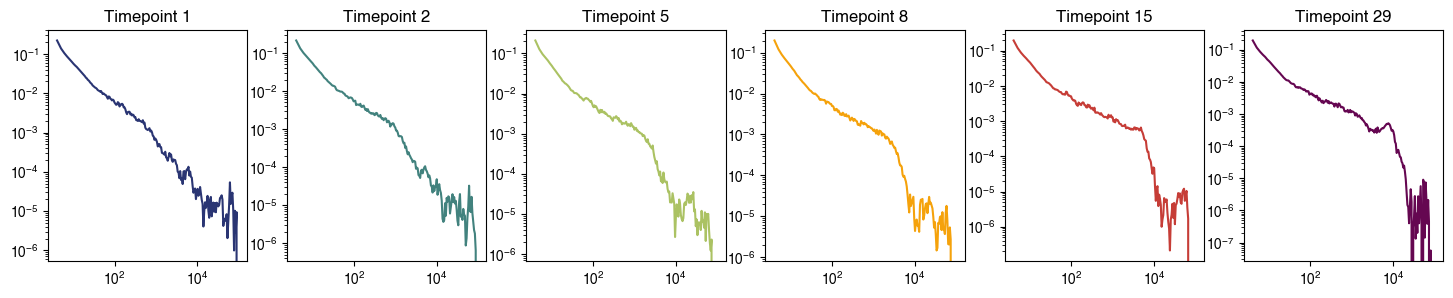

In [19]:
# Plot the P(s) curve as a function of time
from polykit.analysis.polymer_analyses import generate_bins, contact_scaling
colors = cmr.take_cmap_colors(cmr.pride, len(timepoint_list), cmap_range=(0.1, 0.9))
fig, axs = plt.subplots(1, len(timepoint_list), figsize=(18, 3))
for idx_ax, ax in enumerate(axs.flatten()):
    curr_poly = poly[timepoint_list[idx_ax]]
    bins0 = generate_bins(curr_poly.shape[0], bins_per_order_magn=50)
    mid, cp = contact_scaling(curr_poly, bins0=bins0, cutoff=2.5)
    ax.loglog(mid, cp, color=colors[idx_ax])
    ax.set_title(f'Timepoint {timepoint_list[idx_ax]}')